# GeoPulse Intelligence — Commodities & Currency Markets
### Applied Data Analytics and Market Research Assignment

**Datasets:** Brent Oil, Gold (100 years), Silver (100 years), SWIFT Global Currency Tracker

This notebook covers the full assignment in one place:
- **Part I** — Data Analytics Component (30 questions: preparation, descriptive stats, trend/visual analytics, currency tracker, comparisons)
- **Part II** — Market Research Component (linking global events to the data)
- **Bonus** — B1–B6 (% change, correlation, heat map, scatter, moving average, forecast)

All figures are displayed inline below their code cell **and** saved as PNGs to `OUTPUT_DIR`.
Run the whole notebook top to bottom (**Run All**), then use the last cell to download every
output as a single ZIP.

> **Kaggle setup:** Add the 4 CSVs as a Kaggle Dataset ("Add Data" in the right sidebar) before running.
> The path-finder cell below searches `/kaggle/input/` automatically — no path editing needed in most cases.

In [1]:
# ------------------------------------------------------------------
# SETUP — works on Kaggle and locally without editing paths
# ------------------------------------------------------------------
import os, glob, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, FileLink

pd.set_option("display.max_rows", 40)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

# Where to save all charts + the workbook
OUTPUT_DIR = "/kaggle/working/outputs" if os.path.exists("/kaggle/working") else "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SEARCH_ROOTS = ["/kaggle/input", "data", "."]

def _normalize(name):
    """Lowercase and strip spaces/underscores/hyphens so filename variants
    like 'Gold 100years.csv', 'Gold_100Years.csv', 'gold100years.csv' all match."""
    return name.lower().replace(" ", "").replace("_", "").replace("-", "")

def find_file(*candidates):
    """Fuzzy-match a filename anywhere under the search roots (any folder depth),
    ignoring case, spaces, underscores and hyphens. Handles Kaggle's nested
    /kaggle/input/datasets/<user>/<dataset-name>/... structure automatically."""
    all_csvs = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            all_csvs += glob.glob(os.path.join(root, "**", "*.csv"), recursive=True)

    norm_candidates = [_normalize(c) for c in candidates]

    # Pass 1: exact normalized match
    for path in all_csvs:
        if _normalize(os.path.basename(path)) in norm_candidates:
            return path

    # Pass 2: partial match, in case the real filename has extra text
    for path in all_csvs:
        norm_name = _normalize(os.path.basename(path))
        if any(nc in norm_name or norm_name in nc for nc in norm_candidates):
            return path

    raise FileNotFoundError(
        f"Could not find any of {candidates} under {SEARCH_ROOTS}.\n"
        f"CSV files actually found: {[os.path.basename(p) for p in all_csvs]}\n"
        f"Add the dataset via 'Add Data' on Kaggle, or place the CSVs in a 'data/' folder."
    )

print("Output directory:", OUTPUT_DIR)
print("Search roots:", SEARCH_ROOTS)

Output directory: /kaggle/working/outputs
Search roots: ['/kaggle/input', 'data', '.']


## A. Data Preparation and Understanding (Q1–Q5)

In [2]:
# Q1-Q4: load, clean, add Year/Month columns
def load_commodity(path, value_name):
    df = pd.read_csv(path)
    df.columns = [c.strip().strip('"').strip("\ufeff") for c in df.columns]
    df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df = df.rename(columns={"Value": value_name})
    return df.sort_values("Date").reset_index(drop=True)

brent = load_commodity(find_file("Brent_Oil.csv", "Brent Oil.csv"), "Brent")
gold = load_commodity(find_file("Gold_100years.csv", "Gold 100years.csv", "Gold_100Years.csv"), "Gold")
silver = load_commodity(find_file("silver_100_years.csv", "silver 100 years.csv"), "Silver")
swift = pd.read_csv(find_file("swift_currency_tracker_all_reports.csv"))

# Q1 — start/end dates | Q2 — row counts | Q3 — missing values & duplicate dates
summary = pd.DataFrame({
    "Dataset": ["Brent Oil", "Gold", "Silver", "SWIFT Tracker"],
    "Start": [brent["Date"].min().date(), gold["Date"].min().date(), silver["Date"].min().date(), swift["report_month"].iloc[0]],
    "End":   [brent["Date"].max().date(), gold["Date"].max().date(), silver["Date"].max().date(), swift["report_month"].iloc[-1]],
    "Rows": [len(brent), len(gold), len(silver), len(swift)],
    "Missing values (core cols)": [
        brent[["Date","Brent"]].isna().sum().sum(),
        gold[["Date","Gold"]].isna().sum().sum(),
        silver[["Date","Silver"]].isna().sum().sum(),
        swift[["report_month","data_month","metric","currency_or_economy","value"]].isna().sum().sum(),
    ],
    "Duplicate dates": [brent["Date"].duplicated().sum(), gold["Date"].duplicated().sum(),
                        silver["Date"].duplicated().sum(), "n/a (long format)"],
})
print("Q1-Q3 — Dataset summary and data quality check")
display(summary)
print("\nNote: SWIFT's optional columns (rmb_global_rank, notes) are blank for many rows by design —")
print("they only apply to certain metrics (e.g. rank only applies to ranking-type rows). This is not a data-quality issue.")

Q1-Q3 — Dataset summary and data quality check


,Dataset,Start,End,Rows,Missing values (core cols),Duplicate dates
0,Brent Oil,1946-01-01,2026-03-01,963,0,0
1,Gold,1915-01-01,2026-04-01,1336,0,0
2,Silver,1915-01-01,2026-04-01,1336,0,0
3,SWIFT Tracker,January 2026,March 2026,330,42,n/a (long format)



Note: SWIFT's optional columns (rmb_global_rank, notes) are blank for many rows by design —
they only apply to certain metrics (e.g. rank only applies to ranking-type rows). This is not a data-quality issue.


In [3]:
# Q4 — cleaning note
print("Q4 — Cleaning note")
print("Date columns were stored as text (MM/DD/YYYY) and converted to proper datetime type.")
print("Year and Month columns were derived from Date for Brent, Gold and Silver.")
print("No rows were dropped: no missing values or duplicate dates were found in any commodity file.")

Q4 — Cleaning note
Date columns were stored as text (MM/DD/YYYY) and converted to proper datetime type.
Year and Month columns were derived from Date for Brent, Gold and Silver.
No rows were dropped: no missing values or duplicate dates were found in any commodity file.


In [4]:
# Q5 — main metrics available in the SWIFT dataset
q5 = swift.groupby(["metric", "category"]).size().reset_index(name="Rows").sort_values("Rows", ascending=False)
print("Q5 — Main metrics available in the SWIFT Currency Tracker dataset")
display(q5)

Q5 — Main metrics available in the SWIFT Currency Tracker dataset


,metric,category,Rows
3,Global Payment Share,Currency Ranking,80
4,International Payment Share (ex-Eurozone),Currency Ranking,80
5,Offshore RMB by Economy,Offshore Economies,60
1,FX Spot Currency Ranking,FX Spot,40
7,Trade Finance Share,Currency Ranking,40
2,FX Spot Economies (RMB),Offshore Economies,24
6,RMB MoM Payment Growth,RMB Activity,4
0,All Currencies MoM Payment Growth,Market Activity,2


## B. Descriptive Analytics (Q6–Q12)

In [5]:
# Q6-Q8 — highest & lowest prices, and the years they occurred
def high_low(df, col):
    hi = df.loc[df[col].idxmax()]
    lo = df.loc[df[col].idxmin()]
    return hi[col], int(hi["Year"]), lo[col], int(lo["Year"])

rows = []
for name, df, col in [("Brent Oil (USD/bbl)", brent, "Brent"), ("Gold (USD/oz)", gold, "Gold"), ("Silver (USD/oz)", silver, "Silver")]:
    hi_v, hi_y, lo_v, lo_y = high_low(df, col)
    rows.append([name, round(hi_v, 2), hi_y, round(lo_v, 2), lo_y])

q6_8 = pd.DataFrame(rows, columns=["Commodity", "Highest", "Year (high)", "Lowest", "Year (low)"])
print("Q6-Q8 — Highest and lowest prices")
display(q6_8)

Q6-Q8 — Highest and lowest prices


,Commodity,Highest,Year (high),Lowest,Year (low)
0,Brent Oil (USD/bbl),211.21,2008,21.11,1946
1,Gold (USD/oz),5277.89,2026,19.25,1915
2,Silver (USD/oz),113.95,2026,0.28,1932


In [6]:
# Q9 — average price by year
brent_annual = brent.groupby("Year")["Brent"].mean().round(2)
gold_annual = gold.groupby("Year")["Gold"].mean().round(2)
silver_annual = silver.groupby("Year")["Silver"].mean().round(2)

annual_avg = pd.DataFrame({"Brent": brent_annual, "Gold": gold_annual, "Silver": silver_annual})
print("Q9 — Average price by year (last 15 years shown; full table saved to workbook)")
display(annual_avg.tail(15))

Q9 — Average price by year (last 15 years shown; full table saved to workbook)


,Brent,Gold,Silver
Year,,,
2012,135.27,1679.83,31.63
2013,138.30,1399.56,23.53
2014,127.67,1256.25,18.76
2015,68.52,1151.95,15.51
2016,60.79,1249.98,17.13
2017,69.85,1269.34,17.24
2018,84.91,1265.60,15.64
2019,74.03,1405.32,16.36
2020,49.19,1784.66,20.80


In [7]:
# Q10-Q12 — top 5 years by average price, per commodity
def top5(series, label):
    t = series.sort_values(ascending=False).head(5).round(2)
    return pd.DataFrame({label: [f"{y} — {v}" for y, v in t.items()]})

q10 = top5(brent_annual, "Brent Oil")
q11 = top5(gold_annual, "Gold")
q12 = top5(silver_annual, "Silver")
q10_12 = pd.concat([q10, q11, q12], axis=1)
print("Q10-Q12 — Top 5 years by average price")
display(q10_12)

Q10-Q12 — Top 5 years by average price


,Brent Oil,Gold,Silver
0,2008 — 150.96,2026 — 4881.62,2026 — 96.08
1,1980 — 149.86,2025 — 3472.54,2025 — 41.5
2,2011 — 142.12,2024 — 2404.58,2011 — 35.56
3,2013 — 138.3,2023 — 1953.69,2012 — 31.63
4,2012 — 135.27,2022 — 1798.96,2024 — 28.13


## C. Trend and Visual Analytics (Q13–Q18)

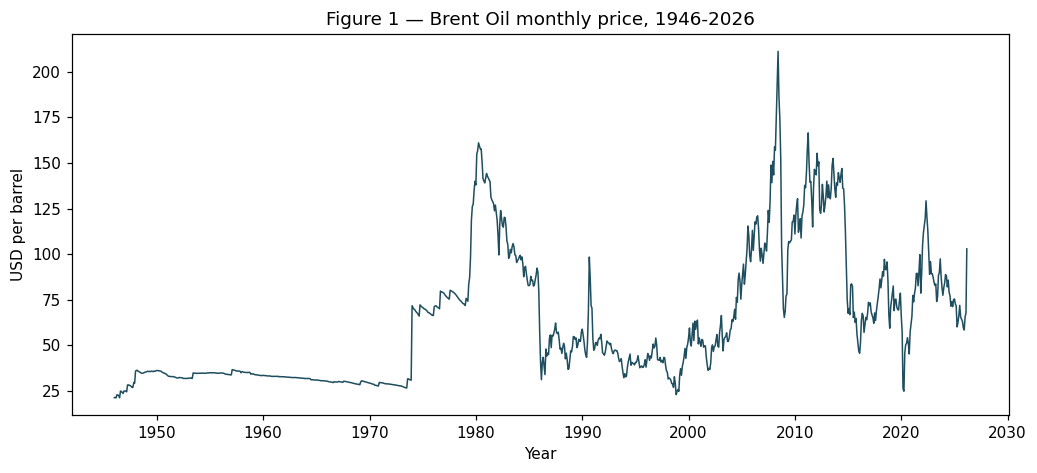

Interpretation:
- Low and stable from the late 1940s through the 1960s.
- First major surge through the 1970s into the early 1980s (oil shocks).
- Volatile climb through the 2000s, peaking in 2008, then a sharp collapse.
- Further slumps in 2015-2016 and 2020, with a sharp renewed spike into 2026.


In [8]:
# Q13 — Figure 1: Brent Oil over time
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(brent["Date"], brent["Brent"], color="#1f4e5f", linewidth=1)
ax.set_title("Figure 1 — Brent Oil monthly price, 1946-2026")
ax.set_xlabel("Year"); ax.set_ylabel("USD per barrel")
fig.savefig(f"{OUTPUT_DIR}/fig1_brent_oil_trend.png")
plt.show()

print("""Interpretation:
- Low and stable from the late 1940s through the 1960s.
- First major surge through the 1970s into the early 1980s (oil shocks).
- Volatile climb through the 2000s, peaking in 2008, then a sharp collapse.
- Further slumps in 2015-2016 and 2020, with a sharp renewed spike into 2026.""")

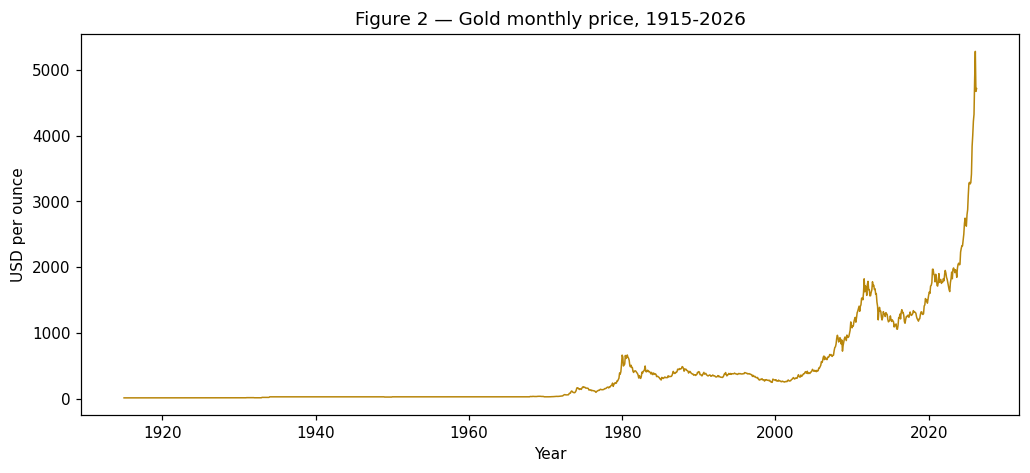

Interpretation:
- Flat for decades under fixed pricing, then a step-up after gold began to float in the 1970s.
- Steady long-term appreciation, accelerating after 2000.
- The steepest climb in the whole series occurs in 2024-2026, reaching record highs.


In [9]:
# Q14 — Figure 2: Gold over time
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(gold["Date"], gold["Gold"], color="#b8860b", linewidth=1)
ax.set_title("Figure 2 — Gold monthly price, 1915-2026")
ax.set_xlabel("Year"); ax.set_ylabel("USD per ounce")
fig.savefig(f"{OUTPUT_DIR}/fig2_gold_trend.png")
plt.show()

print("""Interpretation:
- Flat for decades under fixed pricing, then a step-up after gold began to float in the 1970s.
- Steady long-term appreciation, accelerating after 2000.
- The steepest climb in the whole series occurs in 2024-2026, reaching record highs.""")

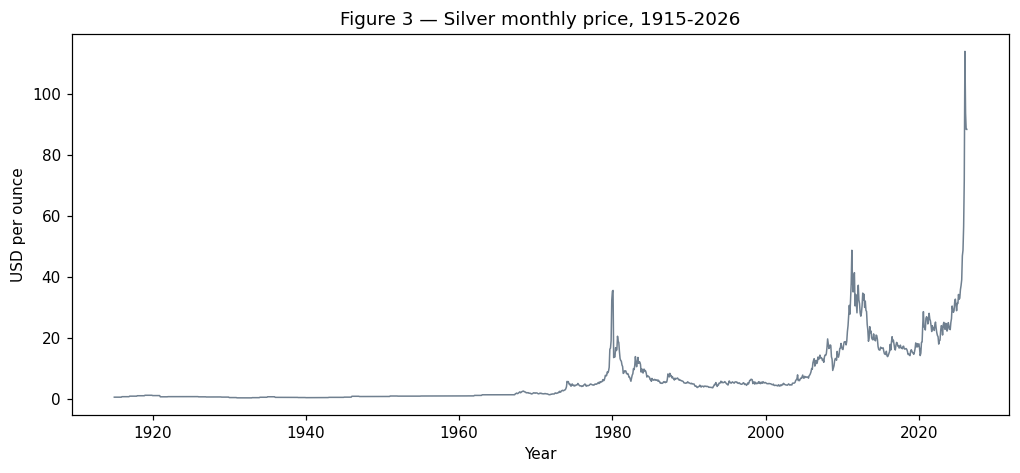

Interpretation:
- Very low and stable for the first half of the century.
- A dramatic peak around 1980, and a second strong peak in 2011.
- A powerful breakout in 2025-2026 to all-time highs.


In [10]:
# Q15 — Figure 3: Silver over time
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(silver["Date"], silver["Silver"], color="#708090", linewidth=1)
ax.set_title("Figure 3 — Silver monthly price, 1915-2026")
ax.set_xlabel("Year"); ax.set_ylabel("USD per ounce")
fig.savefig(f"{OUTPUT_DIR}/fig3_silver_trend.png")
plt.show()

print("""Interpretation:
- Very low and stable for the first half of the century.
- A dramatic peak around 1980, and a second strong peak in 2011.
- A powerful breakout in 2025-2026 to all-time highs.""")

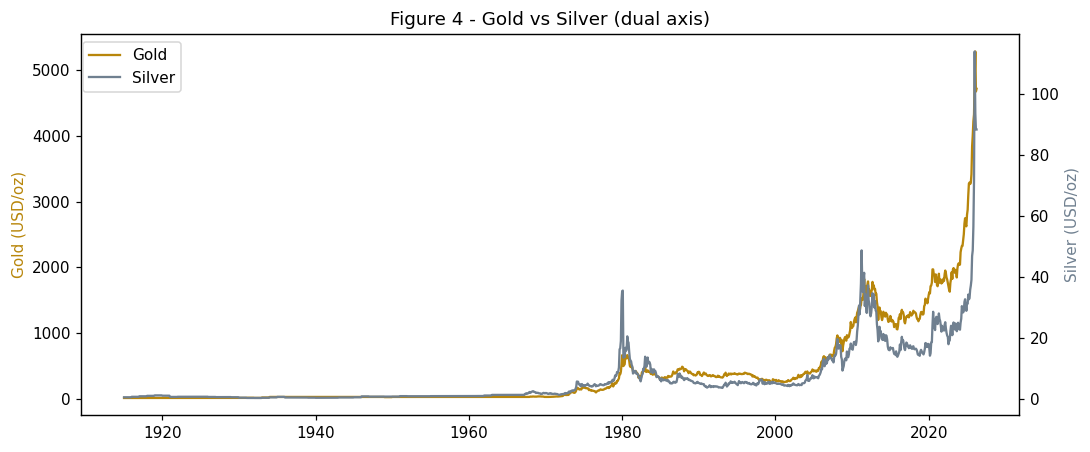

Similarity: both metals broadly move together, sharing the 1980 peak and the 2025-2026 rally.
Difference: silver is far more volatile and trades at a small fraction of gold's price, hence the dual axis.


In [11]:
# Q16 — Figure 4: Gold vs Silver, dual axis
fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax2 = ax1.twinx()
ax1.plot(gold["Date"], gold["Gold"], color="#b8860b", label="Gold")
ax2.plot(silver["Date"], silver["Silver"], color="#708090", label="Silver")
ax1.set_ylabel("Gold (USD/oz)", color="#b8860b")
ax2.set_ylabel("Silver (USD/oz)", color="#708090")
ax1.set_title("Figure 4 - Gold vs Silver (dual axis)")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
fig.savefig(f"{OUTPUT_DIR}/fig4_gold_vs_silver.png")
plt.show()

print("Similarity: both metals broadly move together, sharing the 1980 peak and the 2025-2026 rally.")
print("Difference: silver is far more volatile and trades at a small fraction of gold's price, hence the dual axis.")

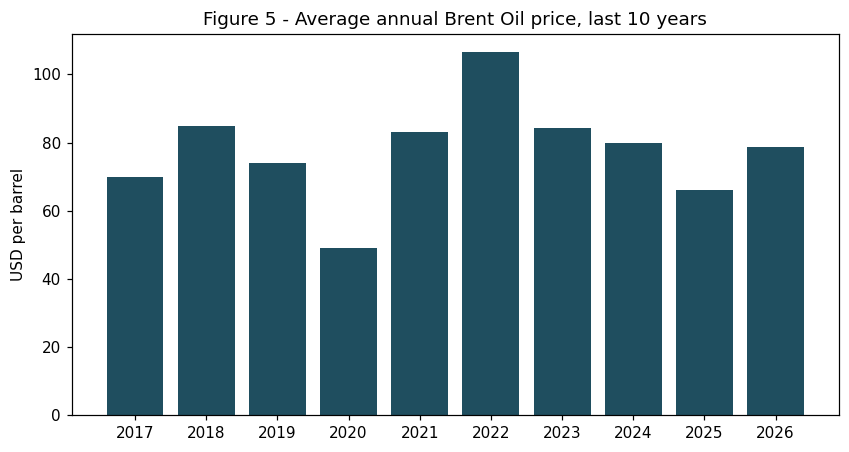

The annual average bottomed near $49 in 2020, rebounded to about $106 in 2022,
then eased through 2023-2025 before rising again at the latest reading.


In [12]:
# Q17 — Figure 5: Average annual Brent Oil, last 10 years
last10 = brent_annual.tail(10)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(last10.index.astype(str), last10.values, color="#1f4e5f")
ax.set_title("Figure 5 - Average annual Brent Oil price, last 10 years")
ax.set_ylabel("USD per barrel")
fig.savefig(f"{OUTPUT_DIR}/fig5_brent_last10years.png")
plt.show()

print("The annual average bottomed near $49 in 2020, rebounded to about $106 in 2022,")
print("then eased through 2023-2025 before rising again at the latest reading.")

In [13]:
# Q18 — latest available value for each commodity
latest = pd.DataFrame({
    "Commodity": ["Brent Oil", "Gold", "Silver"],
    "Latest date": [brent["Date"].max().date(), gold["Date"].max().date(), silver["Date"].max().date()],
    "Latest value": [brent["Brent"].iloc[-1], gold["Gold"].iloc[-1], silver["Silver"].iloc[-1]],
})
print("Q18 - Latest available values")
display(latest)

Q18 - Latest available values


,Commodity,Latest date,Latest value
0,Brent Oil,2026-03-01,102.8600
1,Gold,2026-04-01,4712.8906
2,Silver,2026-04-01,88.3600


## D. Currency Tracker Analytics (Q19–Q24)

In [14]:
# Q19 — top currencies by global payment share, most recent month
gps = swift[swift["metric"] == "Global Payment Share"].copy()
gps["data_month_dt"] = pd.to_datetime(gps["data_month"], format="%B %Y", errors="coerce")
latest_month = gps["data_month_dt"].max()
top_currencies = gps[gps["data_month_dt"] == latest_month].sort_values("value", ascending=False)

print(f"Q19 - Top currencies by global payment share ({latest_month:%B %Y})")
display(top_currencies[["currency_or_economy", "value"]].head(10).rename(
    columns={"currency_or_economy": "Currency", "value": "Share (%)"}))

Q19 - Top currencies by global payment share (March 2026)


,Currency,Share (%)
166,USD,51.14
167,EUR,21.30
168,GBP,6.54
169,JPY,3.53
170,CNY,3.10
171,CAD,3.03
172,HKD,1.76
173,AUD,1.61
174,SGD,1.23
175,CHF,1.07


In [15]:
# Q20-Q21 — USD share, and CNY share + rank
usd_row = top_currencies[top_currencies["currency_or_economy"] == "USD"].iloc[0]
cny_row = top_currencies[top_currencies["currency_or_economy"] == "CNY"].iloc[0]
cny_rank = int(top_currencies.reset_index(drop=True).index[top_currencies["currency_or_economy"].values == "CNY"][0]) + 1

print(f"Q20 - USD share in the most recent global payment data: {usd_row['value']}% ({latest_month:%B %Y})")
print(f"Q21 - CNY/RMB share: {cny_row['value']}%, ranked #{cny_rank} ({latest_month:%B %Y})")

Q20 - USD share in the most recent global payment data: 51.14% (March 2026)
Q21 - CNY/RMB share: 3.1%, ranked #5 (March 2026)


In [16]:
# Q22 — which currencies appear most often in the top 5 across all reports
top5_counts = (gps.sort_values(["data_month_dt", "value"], ascending=[True, False])
                  .groupby("data_month_dt")
                  .head(5)["currency_or_economy"]
                  .value_counts()
                  .rename_axis("Currency")
                  .reset_index(name="Times in top 5"))
print("Q22 - Currency frequency in the top 5 across all available reports")
display(top5_counts)

Q22 - Currency frequency in the top 5 across all available reports


,Currency,Times in top 5
0,USD,4
1,EUR,4
2,GBP,4
3,JPY,4
4,CAD,2
5,CNY,2


In [17]:
# Q23 — highest offshore RMB economy
offshore = swift[swift["metric"].str.contains("Offshore RMB", case=False, na=False)].copy()
offshore["data_month_dt"] = pd.to_datetime(offshore["data_month"], format="%B %Y", errors="coerce")
latest_offshore_month = offshore["data_month_dt"].max()
top_offshore = offshore[offshore["data_month_dt"] == latest_offshore_month].sort_values("value", ascending=False)

print(f"Q23 - Highest offshore RMB economy ({latest_offshore_month:%B %Y})")
display(top_offshore[["currency_or_economy", "value"]].head(5).rename(
    columns={"currency_or_economy": "Economy", "value": "Share (%)"}))

Q23 - Highest offshore RMB economy (March 2026)


,Economy,Share (%)
207,Hong Kong,75.23
208,United Kingdom,6.90
209,Singapore,4.37
210,United States,2.81
211,France,1.80


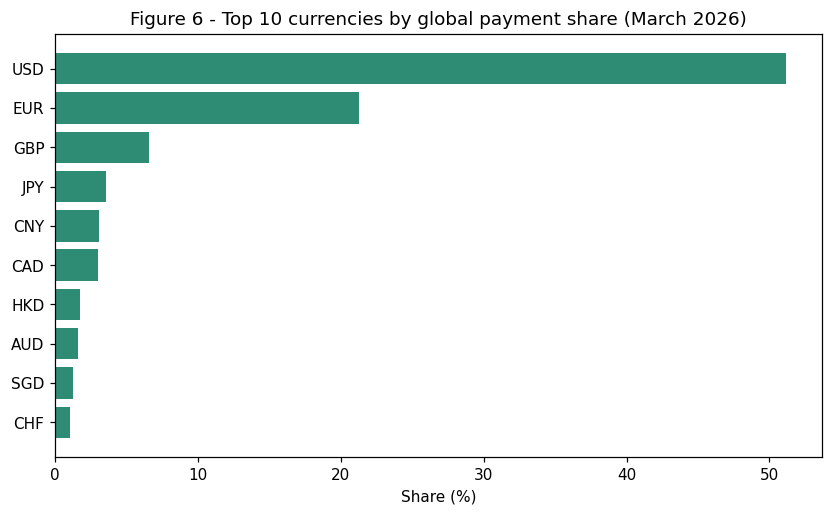

USD dominates at over 50%, the Euro is a distant second, and shares fall away steeply from third place onward.


In [18]:
# Q24 — Figure 6: bar chart, top 10 currencies/economies, selected month
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = top_currencies.head(10).sort_values("value")
ax.barh(plot_data["currency_or_economy"], plot_data["value"], color="#2e8b74")
ax.set_title(f"Figure 6 - Top 10 currencies by global payment share ({latest_month:%B %Y})")
ax.set_xlabel("Share (%)")
fig.savefig(f"{OUTPUT_DIR}/fig6_top10_currencies.png")
plt.show()

print("USD dominates at over 50%, the Euro is a distant second, and shares fall away steeply from third place onward.")

## E. Simple Comparison Questions (Q25–Q30)

In [19]:
# Q25-Q26 — latest vs long-term average
def latest_vs_avg(df, col):
    latest_v = df[col].iloc[-1]
    avg_v = df[col].mean()
    position = "Above average" if latest_v > avg_v else "Below average"
    return round(latest_v, 2), round(avg_v, 2), position

g_latest, g_avg, g_pos = latest_vs_avg(gold, "Gold")
b_latest, b_avg, b_pos = latest_vs_avg(brent, "Brent")

q25_26 = pd.DataFrame({
    "Commodity": ["Gold", "Brent Oil"],
    "Latest value": [g_latest, b_latest],
    "Full-series average": [g_avg, b_avg],
    "Position": [g_pos, b_pos],
})
print("Q25-Q26 - Latest value vs long-term average")
display(q25_26)

Q25-Q26 - Latest value vs long-term average


,Commodity,Latest value,Full-series average,Position
0,Gold,4712.89,397.55,Above average
1,Brent Oil,102.86,62.71,Above average


In [20]:
# Q27 — which commodity has the largest visible price swings (CoV + monthly volatility)
def cov(series):
    return round(series.std() / series.mean() * 100, 1)

def monthly_vol(series):
    return round(series.pct_change().std() * 100, 1)

q27 = pd.DataFrame({
    "Commodity": ["Brent Oil", "Gold", "Silver"],
    "Variation in annual avg (CoV %)": [cov(brent_annual), cov(gold_annual), cov(silver_annual)],
    "Monthly return volatility (%)": [monthly_vol(brent.set_index('Date')['Brent']),
                                       monthly_vol(gold.set_index('Date')['Gold']),
                                       monthly_vol(silver.set_index('Date')['Silver'])],
})
print("Q27 - Price swing comparison")
display(q27)
print("Gold and Silver show the largest long-run range (highest CoV); Brent Oil has the largest month-to-month volatility.")

Q27 - Price swing comparison


,Commodity,Variation in annual avg (CoV %),Monthly return volatility (%)
0,Brent Oil,55.6,9.1
1,Gold,173.4,4.3
2,Silver,171.4,7.7


Gold and Silver show the largest long-run range (highest CoV); Brent Oil has the largest month-to-month volatility.


In [21]:
# Q28 — a year with a strong oil move: did gold/silver also move? (2007-2009 example)
q28 = pd.DataFrame({
    "Year": [2007, 2008, 2009],
    "Brent (avg)": [brent_annual.get(2007), brent_annual.get(2008), brent_annual.get(2009)],
    "Gold (avg)": [gold_annual.get(2007), gold_annual.get(2008), gold_annual.get(2009)],
    "Silver (avg)": [silver_annual.get(2007), silver_annual.get(2008), silver_annual.get(2009)],
})
print("Q28 - Oil price movement year vs Gold/Silver (2007-2009)")
display(q28)
print("During oil's 2008 spike both metals also rose; when oil fell in 2009, gold kept climbing —")
print("showing gold's drivers are not identical to oil's.")

Q28 - Oil price movement year vs Gold/Silver (2007-2009)


,Year,Brent (avg),Gold (avg),Silver (avg)
0,2007,119.10,704.68,13.51
1,2008,150.96,880.21,14.98
2,2009,98.01,982.65,14.77


During oil's 2008 spike both metals also rose; when oil fell in 2009, gold kept climbing —
showing gold's drivers are not identical to oil's.


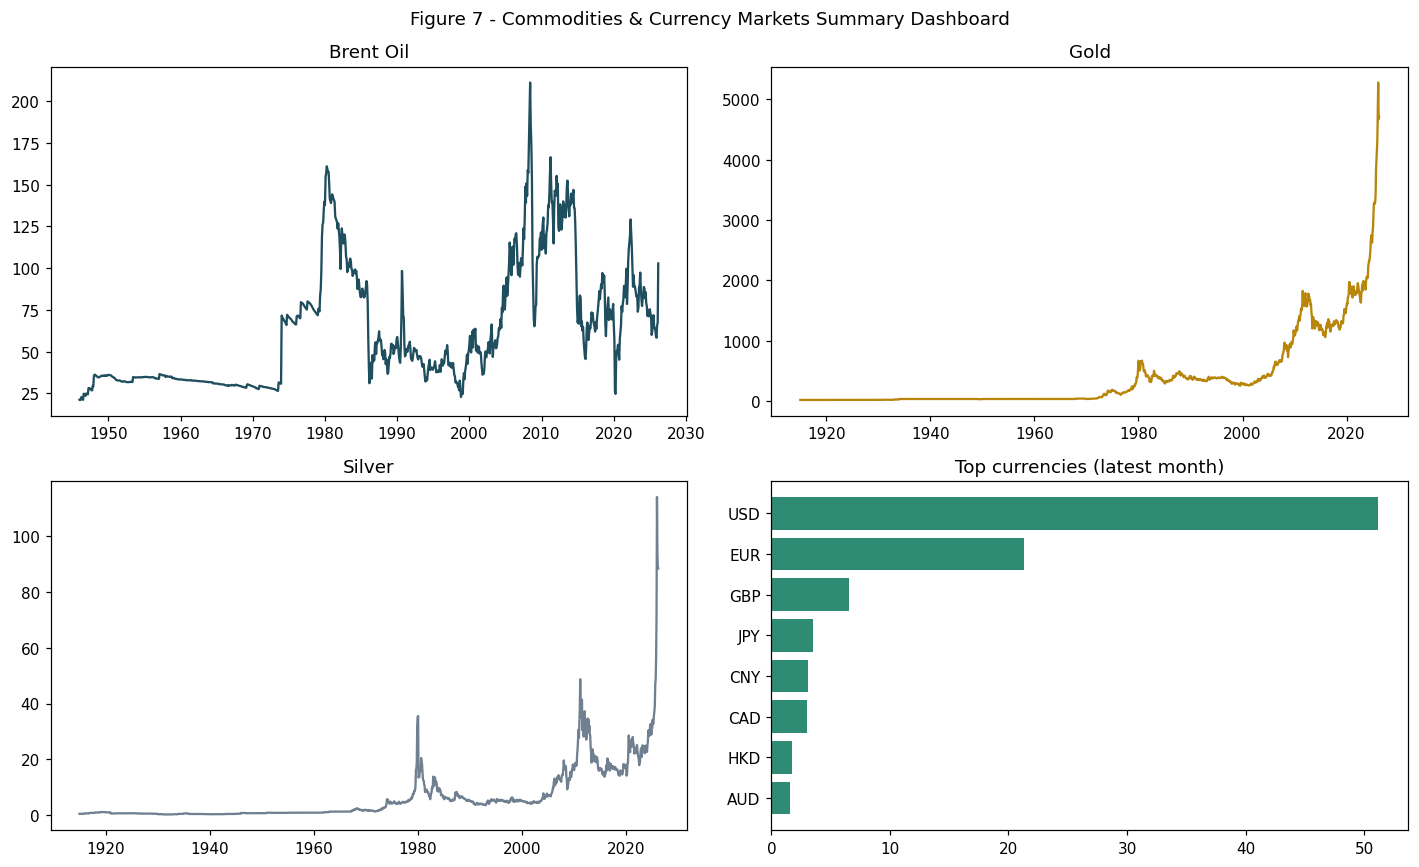

In [22]:
# Q29 — Figure 7: 4-panel summary dashboard
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].plot(brent["Date"], brent["Brent"], color="#1f4e5f"); axes[0, 0].set_title("Brent Oil")
axes[0, 1].plot(gold["Date"], gold["Gold"], color="#b8860b"); axes[0, 1].set_title("Gold")
axes[1, 0].plot(silver["Date"], silver["Silver"], color="#708090"); axes[1, 0].set_title("Silver")
dash_data = top_currencies.head(8).sort_values("value")
axes[1, 1].barh(dash_data["currency_or_economy"], dash_data["value"], color="#2e8b74")
axes[1, 1].set_title("Top currencies (latest month)")
fig.suptitle("Figure 7 - Commodities & Currency Markets Summary Dashboard")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/fig7_dashboard.png")
plt.show()

**Q30 — Three insights a manager could understand without technical knowledge:**
- Precious metals are at record highs — gold and silver have surged to all-time peaks in 2025-2026.
- Oil is the most event-sensitive commodity, with the largest short-term price swings of the three.
- The US Dollar still dominates global payments at roughly half of all transactions, while the Chinese Renminbi sits well back in the rankings.


---
# Part II: Market Research Component

This section links the data patterns above to the global events described in the supporting
reports (Wall Street Ledger, Reserve Storm, and the "Critical New Context" briefing).


## A. Event Identification

**Event 1 — US-Israel Military Operation Against Iran & Hormuz Crisis (February 28, 2026).**
The most impactful event in the dataset. Large-scale strikes against Iranian nuclear facilities began
on February 28, 2026; Iran retaliated by disrupting the Strait of Hormuz (~20% of world oil exports).
Brent crude rose from **$67.66 (Feb 2026) to $102.86 (Mar 2026)** — a 52% one-month spike (Figure 1).

**Event 2 — BRICS Gold Accumulation & De-dollarisation Push.**
BRICS countries ran an organised campaign of physical gold accumulation (710 tonnes in Q3 2025, ~900
tonnes expected for full-year 2026), creating a price floor around $4,300 and pushing Gold to an
all-time peak of **$5,277.89 in February 2026** (Figure 2).

**Event 3 — US Tariffs, Sanctions & BRICS Payment Alternatives.**
A 20% BRICS tariff took effect January 21, 2026, alongside a proposed 40% "war tariff" tied to Iranian
cryptocurrency payments. BRICS Pay volume doubled to ~$4bn/month since the Hormuz blockade, and an
emergency BRICS stablecoin (gold + oil + yuan) launched in April 2026 — visible in the SWIFT data as
CNY holding the #2 spot in trade finance at 8.04%.


**Timeline of selected events:**

| Date | Event | Market impact |
|---|---|---|
| Oct 2025 | Gold intraday ATH $4,379.60; Silver breaks $50 for first time since 1980 | Safe-haven demand building |
| Oct 2025 | Saudi Aramco invoices China in non-dollar currencies | Petrodollar framework cracks |
| Oct 2025 | BRICS Kazan Summit — multipolar financial order discussed | CNY/BRICS currency push |
| Jan 21, 2026 | GOP House win — 20% BRICS tariff, Day 1 | Trade war escalation |
| Jan 2026 | Silver ATH $113.95; Gold reaches $4,865 | Industrial + safe-haven peak |
| Jan 29, 2026 | Gold intraday ATH $5,595 | Crisis fear premium at maximum |
| Feb 28, 2026 | US-Israel strikes on Iran begin; Hormuz disrupted | Oil: $67.66 -> $102.86 in one month |
| Mar 2026 | Brent Oil peaks at $102.86/barrel | Largest supply disruption since 1970s |
| Apr 7, 2026 | Temporary ceasefire agreed | Brief market relief |
| Apr 8, 2026 | Saudi Petroline pipeline struck; GCC growth downgraded | Energy infrastructure under attack |
| Apr 2026 | BRICS emergency stablecoin launched (gold+oil+yuan) | Alternative payment rails accelerate |

**Most directly connected to Brent Oil:** the Iran war and Hormuz disruption (Feb 28, 2026) — the 52%
one-month spike is the clearest single event-to-price link in the dataset (Figure 1).

**Most directly connected to Gold/Silver:** two distinct drivers at different times — Silver peaked
first (Jan 2026, industrial demand from green energy/EVs/defence spending), Gold peaked a month later
(Feb 2026, safe-haven demand from the Iran war) (Figure 4).


## B. Linking Events to Commodity Data

**Oil supply shock -> Brent price (Figure 1).** Hormuz carries ~20% of the world's seaborne oil; blocking
it forces buyers to source elsewhere, while futures traders price in a "risk premium" even before physical
shortage hits. Brent rose from $67.66 to $102.86 in one month — one of the sharpest single-month moves in
the whole 1946-2026 series.

**Gold and geopolitical uncertainty (Figure 2).** Gold carries no counterparty risk — it can't be
sanctioned, frozen, or printed — which is exactly why it re-rates upward when trust in currencies and
institutions erodes. Three forces compounded in 2026: a declining USD reserve share, oil-driven inflation
fears, and BRICS central-bank gold buying. Gold is now roughly 1,000%+ above its long-run average.

**Silver's dual identity.** Silver peaked in January 2026 — a month *before* the war — most plausibly
driven by industrial demand (solar, EVs, defence electronics) rather than fear. It then fell back from
its January peak through February-April even as Gold kept climbing, evidence that in this period silver
behaved more like an industrial commodity than a pure safe haven.

**Crisis-period comparison (Feb-Mar 2026):**

| Asset | Pre-war (Feb 2026) | Mar 2026 | Change | Behaviour |
|---|---|---|---|---|
| Brent Oil | $67.66 | $102.86 | +52.0% | Explosive surge — direct supply shock |
| Gold | $5,277.89 (ATH) | $4,670.35 | -11.5% | Peaked at war start, then partial pullback |
| Silver | $93.66 | $88.36 | -5.7% | Already falling from its Jan peak |


## C. Linking Events to Currency Data

**USD's role (Q19-Q20).** USD accounts for roughly half of global SWIFT payments and an even larger
share once intra-Eurozone payments are excluded. Notably the USD share *dipped* in January-February 2026
before *rising* again in March, right as the Iran war intensified — a "flight to safety" / "dollar smile"
pattern in which USD weakens in calm periods and strengthens in crises.

**CNY/RMB's split role (Q21).** In *general* cross-border payments CNY remains a minor player (single-digit
percent, mid-table rank). But in *trade finance* specifically, CNY holds the #2 spot (8.04%) — evidence
that Belt & Road-style bilateral yuan settlement in physical trade is structurally ahead of CNY's role in
everyday payments.

**Why alternative settlement rails matter.** Sanctions determine which currencies are usable at all — once
cut off from SWIFT, a currency effectively becomes unusable internationally (as happened to the Russian
rouble). BRICS Pay (~$4bn/month, doubled since the Hormuz blockade) and the April 2026 gold+oil+yuan
stablecoin show a parallel payment system already emerging alongside SWIFT.

**Hong Kong's concentration (Q23).** Hong Kong holds the large majority of offshore RMB flow, which
makes it structurally indispensable to RMB internationalisation, but also a single point of concentration
risk for the whole offshore RMB system.


## D. Business Interpretation and Recommendation

**Which market is most event-sensitive?** Oil reacts fastest and hardest to a single event (52% in one
month) because physical delivery has no substitute in the short run. Gold is most *structurally* sensitive
— its ~1,000% premium over its long-run average reflects years of accumulated distrust (QE, wars,
de-dollarisation), not one event. Currencies are the most complex, blending safe-haven flows, structural
de-dollarisation, and central bank policy simultaneously.

**Risk note — oil price exposure.** Businesses with oil-linked costs or revenue face a high-risk
environment after the 52% Feb-Mar 2026 spike driven by the Hormuz blockade. Manufacturing, logistics,
aviation and chemicals see direct margin exposure. Futures hedging from a 3-month horizon is reasonable,
with scenario planning for both a "sustained disruption" case (~$120-130/bbl) and a "ceasefire/resolution"
case (price retracing to ~$65-70/bbl) — hedging should account for both directions.

**Risk note — USD / Gold / RMB holdings.** USD remains dominant short-term but faces a slow structural
decline in reserve share; Gold's central-bank-driven floor makes it a reasonable inflation/geopolitical
hedge; RMB is rising fast in trade finance specifically but still carries Hong Kong concentration risk and
capital-control exposure.

**Three practical recommendations:**
1. Diversify energy exposure and suppliers away from Hormuz-dependent routes — a single choke point can
   remove ~20% of world oil supply within a week.
2. Treat gold as a strategic reserve rather than a speculative trade, given sustained central-bank buying.
3. Monitor the SWIFT currency tracker monthly as an early-warning system — the CNY trade-finance dip and
   the USD payment-share dip both preceded visible market stress by several weeks.


---
# Optional Bonus Analytics (B1-B6)


B1 - Annual % change, 2015 onward


,Brent_%chg,Gold_%chg,Silver_%chg
Year,,,
2015,-46.3,-8.3,-17.3
2016,-11.3,8.5,10.4
2017,14.9,1.5,0.6
2018,21.6,-0.3,-9.3
2019,-12.8,11.0,4.6
2020,-33.6,27.0,27.1
2021,68.8,0.5,20.0
2022,28.2,0.3,-13.2
2023,-20.9,8.6,8.8


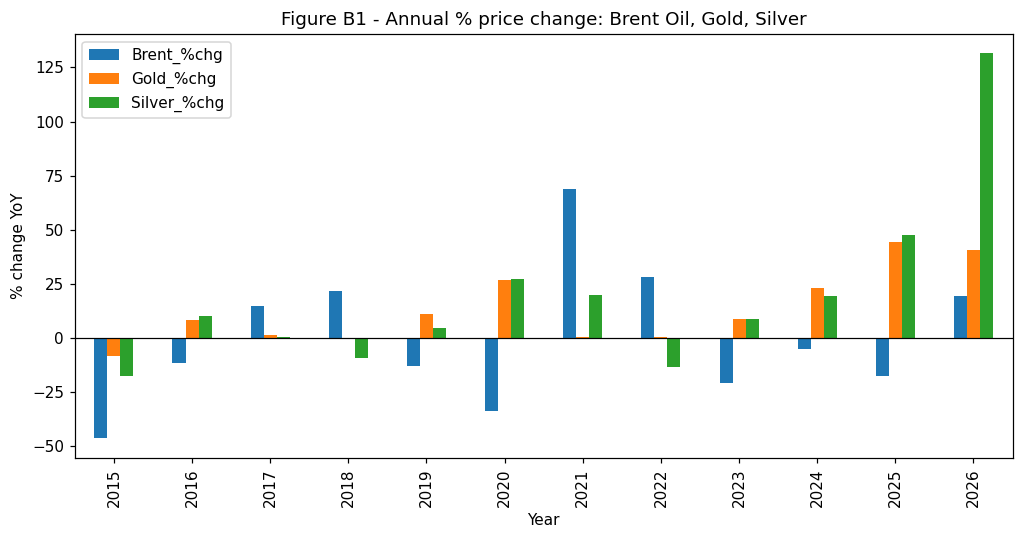

In [23]:
# B1 — annual % change for each commodity
def annual_pct_change(annual_series):
    return (annual_series.pct_change() * 100)

brent_chg = annual_pct_change(brent_annual)
gold_chg = annual_pct_change(gold_annual)
silver_chg = annual_pct_change(silver_annual)

b1_table = pd.DataFrame({"Brent_%chg": brent_chg, "Gold_%chg": gold_chg, "Silver_%chg": silver_chg}).dropna()
b1_recent = b1_table[b1_table.index >= 2015].round(1)

print("B1 - Annual % change, 2015 onward")
display(b1_recent)

fig, ax = plt.subplots(figsize=(11, 5))
b1_recent.plot(kind="bar", ax=ax)
ax.set_title("Figure B1 - Annual % price change: Brent Oil, Gold, Silver")
ax.set_ylabel("% change YoY"); ax.axhline(0, color="black", linewidth=0.8)
fig.savefig(f"{OUTPUT_DIR}/figB1_annual_pct_change.png")
plt.show()

In [24]:
# B2 — correlation table (annual averages)
merged_annual = pd.DataFrame({"Brent": brent_annual, "Gold": gold_annual, "Silver": silver_annual}).dropna()
corr = merged_annual.corr()
print("B2 - Correlation table (annual average prices)")
display(corr.round(4))
print("\nGold and Silver are very strongly correlated; Brent shows only a moderate positive correlation with both metals.")

B2 - Correlation table (annual average prices)


,Brent,Gold,Silver
Brent,1.0000,0.4577,0.5148
Gold,0.4577,1.0000,0.9538
Silver,0.5148,0.9538,1.0000



Gold and Silver are very strongly correlated; Brent shows only a moderate positive correlation with both metals.


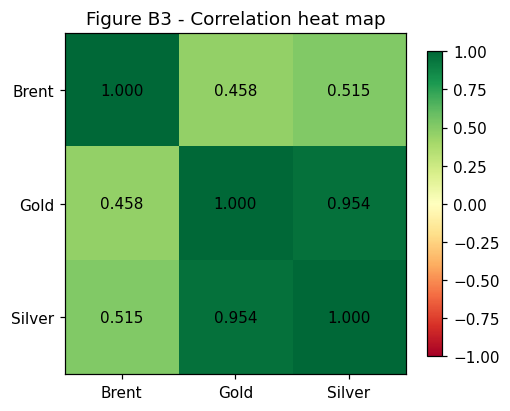

In [25]:
# B3 — correlation heat map
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns)
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.3f}", ha="center", va="center")
ax.set_title("Figure B3 - Correlation heat map")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.savefig(f"{OUTPUT_DIR}/figB3_correlation_heatmap.png")
plt.show()

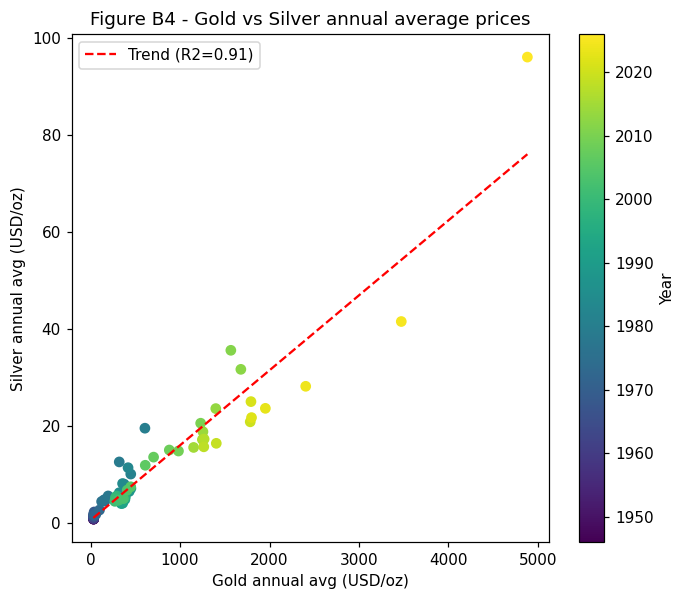

Regression: slope=0.015, intercept=0.48, R2=0.910
The 2026 point sits above the trendline, reflecting silver's outsized late move relative to its historical relationship with gold.


In [26]:
# B4 — scatter: Gold vs Silver annual averages, with trendline
x = merged_annual["Gold"].values
y = merged_annual["Silver"].values
slope, intercept = np.polyfit(x, y, 1)
r2 = np.corrcoef(x, y)[0, 1] ** 2

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(x, y, c=merged_annual.index, cmap="viridis")
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, slope * xs + intercept, "r--", label=f"Trend (R2={r2:.2f})")
ax.set_xlabel("Gold annual avg (USD/oz)"); ax.set_ylabel("Silver annual avg (USD/oz)")
ax.set_title("Figure B4 - Gold vs Silver annual average prices")
ax.legend()
fig.colorbar(sc, ax=ax, label="Year")
fig.savefig(f"{OUTPUT_DIR}/figB4_gold_silver_scatter.png")
plt.show()

print(f"Regression: slope={slope:.3f}, intercept={intercept:.2f}, R2={r2:.3f}")
print("The 2026 point sits above the trendline, reflecting silver's outsized late move relative to its historical relationship with gold.")

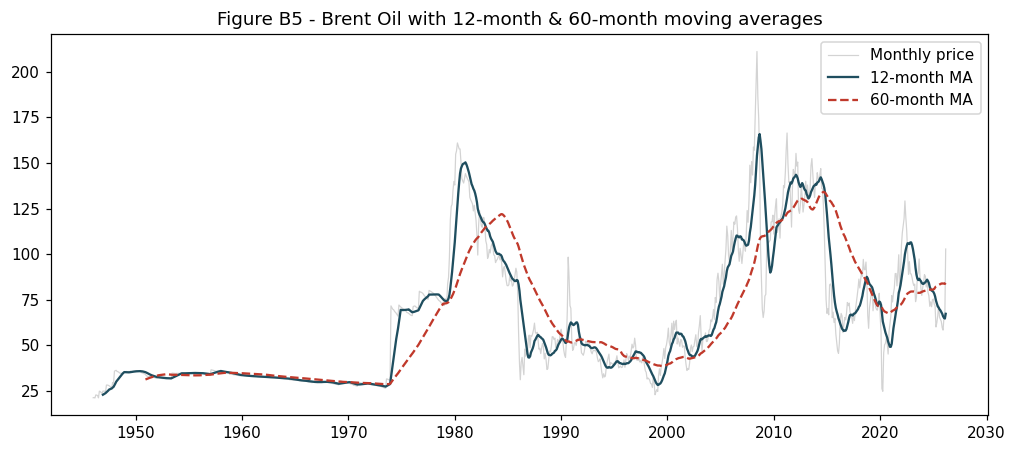

Latest price: 102.86 | 12-month MA: 67.3 | 60-month MA: 84.2
The latest monthly price sits sharply above both moving averages, suggesting a strong short-term breakout.


In [27]:
# B5 — Brent Oil moving averages (12-month & 60-month)
brent_ma = brent.set_index("Date")["Brent"]
ma12 = brent_ma.rolling(12).mean()
ma60 = brent_ma.rolling(60).mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(brent_ma.index, brent_ma.values, color="lightgray", linewidth=0.8, label="Monthly price")
ax.plot(ma12.index, ma12.values, color="#1f4e5f", label="12-month MA")
ax.plot(ma60.index, ma60.values, color="#c0392b", linestyle="--", label="60-month MA")
ax.set_title("Figure B5 - Brent Oil with 12-month & 60-month moving averages")
ax.legend()
fig.savefig(f"{OUTPUT_DIR}/figB5_brent_moving_average.png")
plt.show()

print(f"Latest price: {brent_ma.iloc[-1]:.2f} | 12-month MA: {ma12.iloc[-1]:.1f} | 60-month MA: {ma60.iloc[-1]:.1f}")
print("The latest monthly price sits sharply above both moving averages, suggesting a strong short-term breakout.")

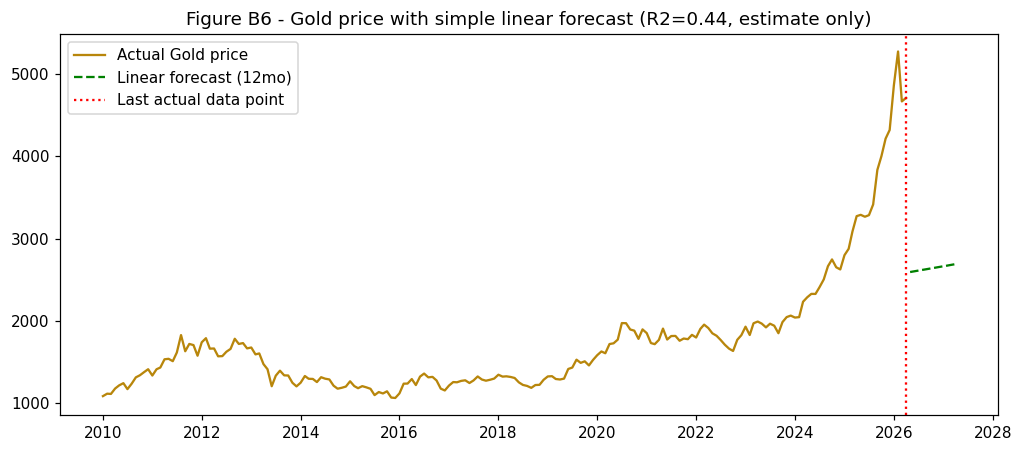

B6 - 12-month linear forecast for Gold (estimate only, not a guaranteed prediction):


,Date,Forecast_Gold
0,2026-05-01,2593.0
1,2026-06-01,2602.0
2,2026-07-01,2611.0
3,2026-08-01,2620.0
4,2026-09-01,2628.0
5,2026-10-01,2637.0
6,2026-11-01,2646.0
7,2026-12-01,2655.0
8,2027-01-01,2663.0
9,2027-02-01,2672.0



IMPORTANT: this is a simple linear-regression estimate. Actual gold prices are driven by
geopolitics, central-bank policy, inflation and sentiment -- a straight line cannot capture these.


In [28]:
# B6 — simple linear forecast for Gold, 12 months ahead
# Methodology: fit on Jan-2010 onward only, matching the assignment's Bonus spec
# ("monthly Gold prices from January 2010 to April 2026"). Using the full 1915-2026
# history would flatten the recent trend and understate it.
gold_series = gold.set_index("Date")["Gold"]
gold_series = gold_series[gold_series.index >= "2010-01-01"]
t = np.arange(len(gold_series))
slope_g, intercept_g = np.polyfit(t, gold_series.values, 1)
r2_g = np.corrcoef(t, gold_series.values)[0, 1] ** 2

future_t = np.arange(len(gold_series), len(gold_series) + 12)
future_dates = pd.date_range(gold_series.index[-1] + pd.offsets.MonthBegin(1), periods=12, freq="MS")
forecast = slope_g * future_t + intercept_g

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(gold_series.index, gold_series.values, color="#b8860b", label="Actual Gold price")
ax.plot(future_dates, forecast, color="green", linestyle="--", label="Linear forecast (12mo)")
ax.axvline(gold_series.index[-1], color="red", linestyle=":", label="Last actual data point")
ax.set_title(f"Figure B6 - Gold price with simple linear forecast (R2={r2_g:.2f}, estimate only)")
ax.legend()
fig.savefig(f"{OUTPUT_DIR}/figB6_gold_forecast.png")
plt.show()

forecast_table = pd.DataFrame({"Date": future_dates.date, "Forecast_Gold": forecast.round(0)})
print("B6 - 12-month linear forecast for Gold (estimate only, not a guaranteed prediction):")
display(forecast_table)
print("\nIMPORTANT: this is a simple linear-regression estimate. Actual gold prices are driven by")
print("geopolitics, central-bank policy, inflation and sentiment -- a straight line cannot capture these.")

---
# Export: Cleaned Workbook + Download Everything as ZIP


In [29]:
# Export cleaned data + summary tables into one Excel workbook
workbook_path = f"{OUTPUT_DIR}/DSB_Full_Cleaned_and_Summary.xlsx"
with pd.ExcelWriter(workbook_path, engine="openpyxl") as writer:
    brent.to_excel(writer, sheet_name="Brent_clean", index=False)
    gold.to_excel(writer, sheet_name="Gold_clean", index=False)
    silver.to_excel(writer, sheet_name="Silver_clean", index=False)
    swift.to_excel(writer, sheet_name="SWIFT_clean", index=False)
    annual_avg.to_excel(writer, sheet_name="Annual_Averages")
    b1_recent.to_excel(writer, sheet_name="B1_Pct_Change")
    corr.round(4).to_excel(writer, sheet_name="B2_Correlation")
    forecast_table.to_excel(writer, sheet_name="B6_Gold_Forecast", index=False)

print("Workbook saved:", workbook_path)

Workbook saved: /kaggle/working/outputs/DSB_Full_Cleaned_and_Summary.xlsx


In [30]:
# Zip every file in OUTPUT_DIR into one downloadable archive
zip_base = "/kaggle/working/GeoPulse_Intelligence_Outputs" if os.path.exists("/kaggle/working") else "GeoPulse_Intelligence_Outputs"
zip_path = shutil.make_archive(zip_base, "zip", OUTPUT_DIR)
print("All outputs zipped to:", zip_path)

display(FileLink(zip_path))

All outputs zipped to: /kaggle/working/GeoPulse_Intelligence_Outputs.zip


/kaggle/working/GeoPulse_Intelligence_Outputs.zip